# Correlation Analysis Between Selected Financial Instruments

The aim of the analysis is to show how prices have changed and whether there are correlations between the prices of selected financial instruments (stock indices, commodities, cryptocurrencies, currency pairs).

### Data load
---

In [1]:
import src.data_loader as dl
import src.analytics as aly
import src.plotting as pl

data = dl.DataManager('../database_2026-03-04')
data.load_everything()

### 1. Market leaders data overview
---

At the beginning, key financial instruments relevant to the study were selected from the dataset, including Bitcoin, Gold, Brent Crude Oil, S&P 500, EURO STOXX 50, and USD/PLN. Daily price changes were then computed based on closing prices from consecutive trading days.

In [2]:
selected = ["Bitcoin", "Gold", "Brent Crude Oil", "S&P 500", "EURO STOXX 50", "USDPLN"]
returns_sel = data.close_returns[selected]
close_prices_sel = data.close_prices[selected]

In the first stage, the key descriptive statistics for daily price changes were computed, including the mean, standard deviation, minimum, maximum, kurtosis, and skewness, among others.

In [3]:
returns_sel.describe().round(3)

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
count,940.000,940.000,940.000,940.000,940.000,940.000
mean,0.001,0.001,0.001,0.000,0.001,0.000
std,0.032,0.011,0.023,0.011,0.011,0.007
min,-0.143,-0.114,-0.244,-0.059,-0.050,-0.040
25%,-0.016,-0.005,-0.011,-0.005,-0.005,-0.004
50%,0.000,0.001,0.002,0.001,0.001,-0.000
75%,0.018,0.007,0.013,0.006,0.007,0.004
max,0.123,0.061,0.138,0.095,0.074,0.030


Średnia

In [4]:
returns_sel.kurtosis().rename("kurtosis")

Bitcoin             2.300565
Gold               13.824296
Brent Crude Oil    16.398710
S&P 500             7.709301
EURO STOXX 50       3.940844
USDPLN              1.918673
Name: kurtosis, dtype: float64

In [5]:
returns_sel.skew().rename("skewness")

Bitcoin           -0.030560
Gold              -1.270935
Brent Crude Oil   -1.282069
S&P 500            0.194915
EURO STOXX 50      0.016356
USDPLN            -0.028171
Name: skewness, dtype: float64

### 2. Market correlation analysis
---

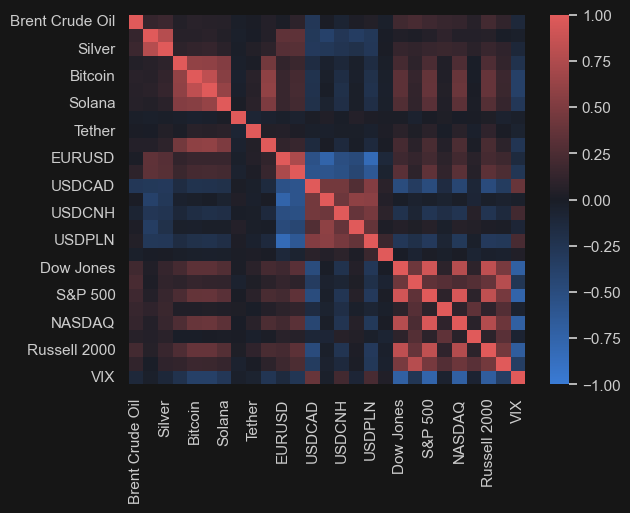

In [6]:
returns = data.close_returns
pear_cor, pear_p_vals = aly.correlations(returns, "pearson")
spear_cor, spear_p_vals = aly.correlations(returns, "spearman")
pl.heatmap_corr(pear_cor)

In [7]:
aly.corr_score(pear_cor, pear_p_vals).rename("Pearson (sum)")

S&P 500            8.023281
USDCAD             7.948879
Russell 2000       7.740882
Dow Jones          7.581100
NASDAQ             7.517464
GBPUSD             7.242148
USDPLN             6.983015
EURUSD             6.754333
VIX                6.554241
Ethereum           6.151198
Bitcoin            6.011640
USDCNH             5.779183
EURO STOXX 50      5.585242
Solana             5.045780
FTSE 100           4.816160
Silver             4.540287
Binance Coin       4.400142
XRP                4.239213
USDCHF             4.112556
Gold               3.436240
USDJPY             3.163355
Hang Seng Index    2.365757
Brent Crude Oil    2.278148
Nikkei 225         1.871149
Tether             0.647484
USDRUB             0.601341
USD Coin           0.083835
Name: Pearson (sum), dtype: float64

In [8]:
aly.corr_score(spear_cor, spear_p_vals).rename("Spearman (sum)")

S&P 500            8.095499
USDCAD             8.042035
Russell 2000       8.008145
GBPUSD             7.723991
NASDAQ             7.583615
Dow Jones          7.489057
USDPLN             7.214311
EURUSD             7.196454
VIX                6.882824
Ethereum           6.720758
Bitcoin            6.569126
USDCNH             6.271613
Binance Coin       5.903617
Solana             5.681995
EURO STOXX 50      5.551855
USDCHF             5.367874
Silver             5.308067
XRP                5.286064
FTSE 100           4.640388
Gold               4.102382
USDJPY             3.260721
Tether             2.379115
Brent Crude Oil    2.238112
Hang Seng Index    2.186818
Nikkei 225         1.809831
USDRUB             1.365414
USD Coin           0.000000
Name: Spearman (sum), dtype: float64

### 3. Market leaders analysis
---

In [9]:
(pear_cor.loc[selected, selected]
 .style.format("{:.3f}")
 .apply(pl.highlight_significant(pear_p_vals.loc[selected, selected]), axis=None))

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
Bitcoin,1.000,0.070,0.072,0.369,0.168,-0.206
Gold,0.070,1.000,0.140,0.050,-0.010,-0.282
Brent Crude Oil,0.072,0.140,1.000,0.185,0.113,0.041
S&P 500,0.369,0.050,0.185,1.000,0.465,-0.303
EURO STOXX 50,0.168,-0.010,0.113,0.465,1.000,-0.282
USDPLN,-0.206,-0.282,0.041,-0.303,-0.282,1.000


In [10]:
reg, reg_pvals = aly.regression(returns_sel)
(reg.loc[selected, selected]
 .style.format("{:.3f}")
 .apply(pl.highlight_significant(reg_pvals.loc[selected, selected]), axis=None))

,Bitcoin,Gold,Brent Crude Oil,S&P 500,EURO STOXX 50,USDPLN
Bitcoin,1.000,0.024,0.051,0.124,0.057,-0.043
Gold,0.204,1.000,0.287,0.049,-0.010,-0.171
Brent Crude Oil,0.101,0.068,1.000,0.087,0.054,0.012
S&P 500,1.101,0.052,0.391,1.000,0.475,-0.189
EURO STOXX 50,0.491,-0.010,0.234,0.456,1.000,-0.173
USDPLN,-0.983,-0.465,0.140,-0.484,-0.460,1.000


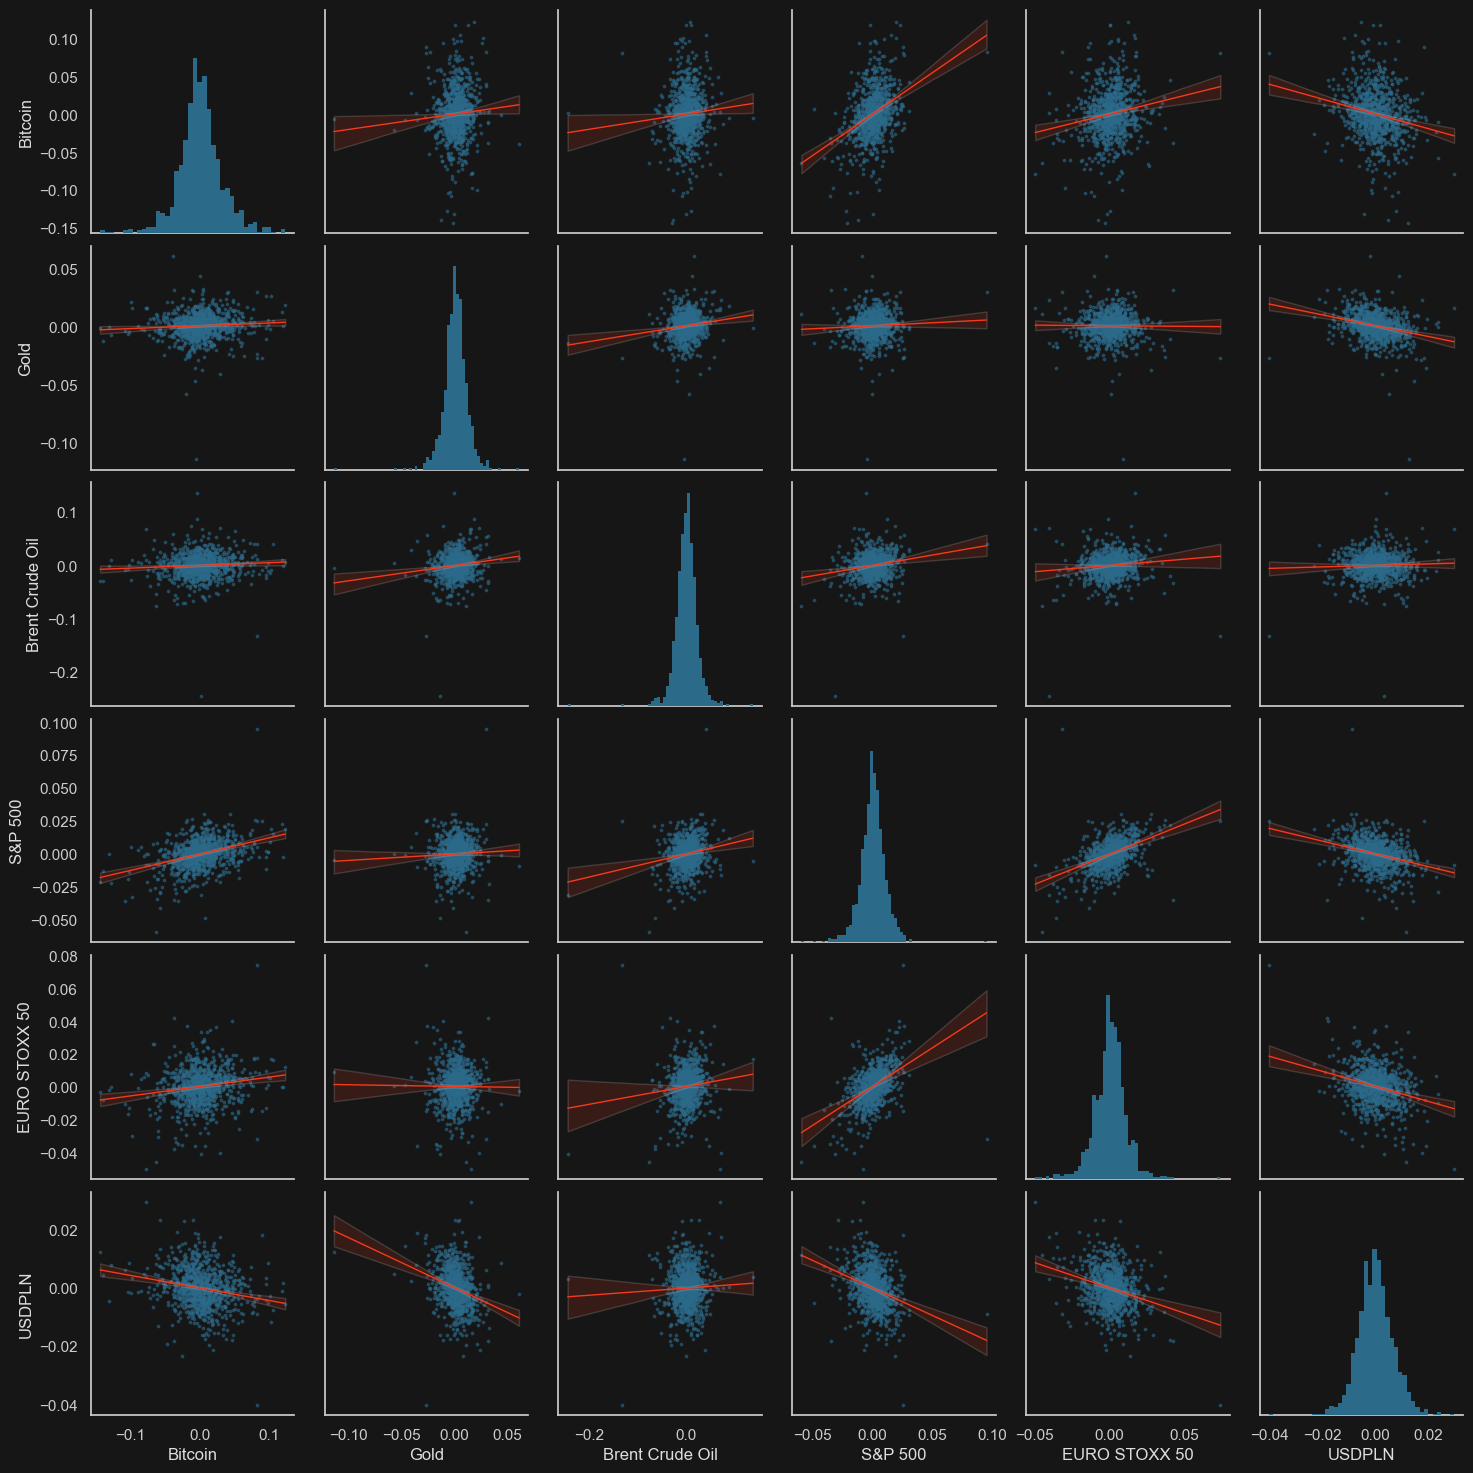

In [11]:
pl.price_change_distributions(returns_sel)

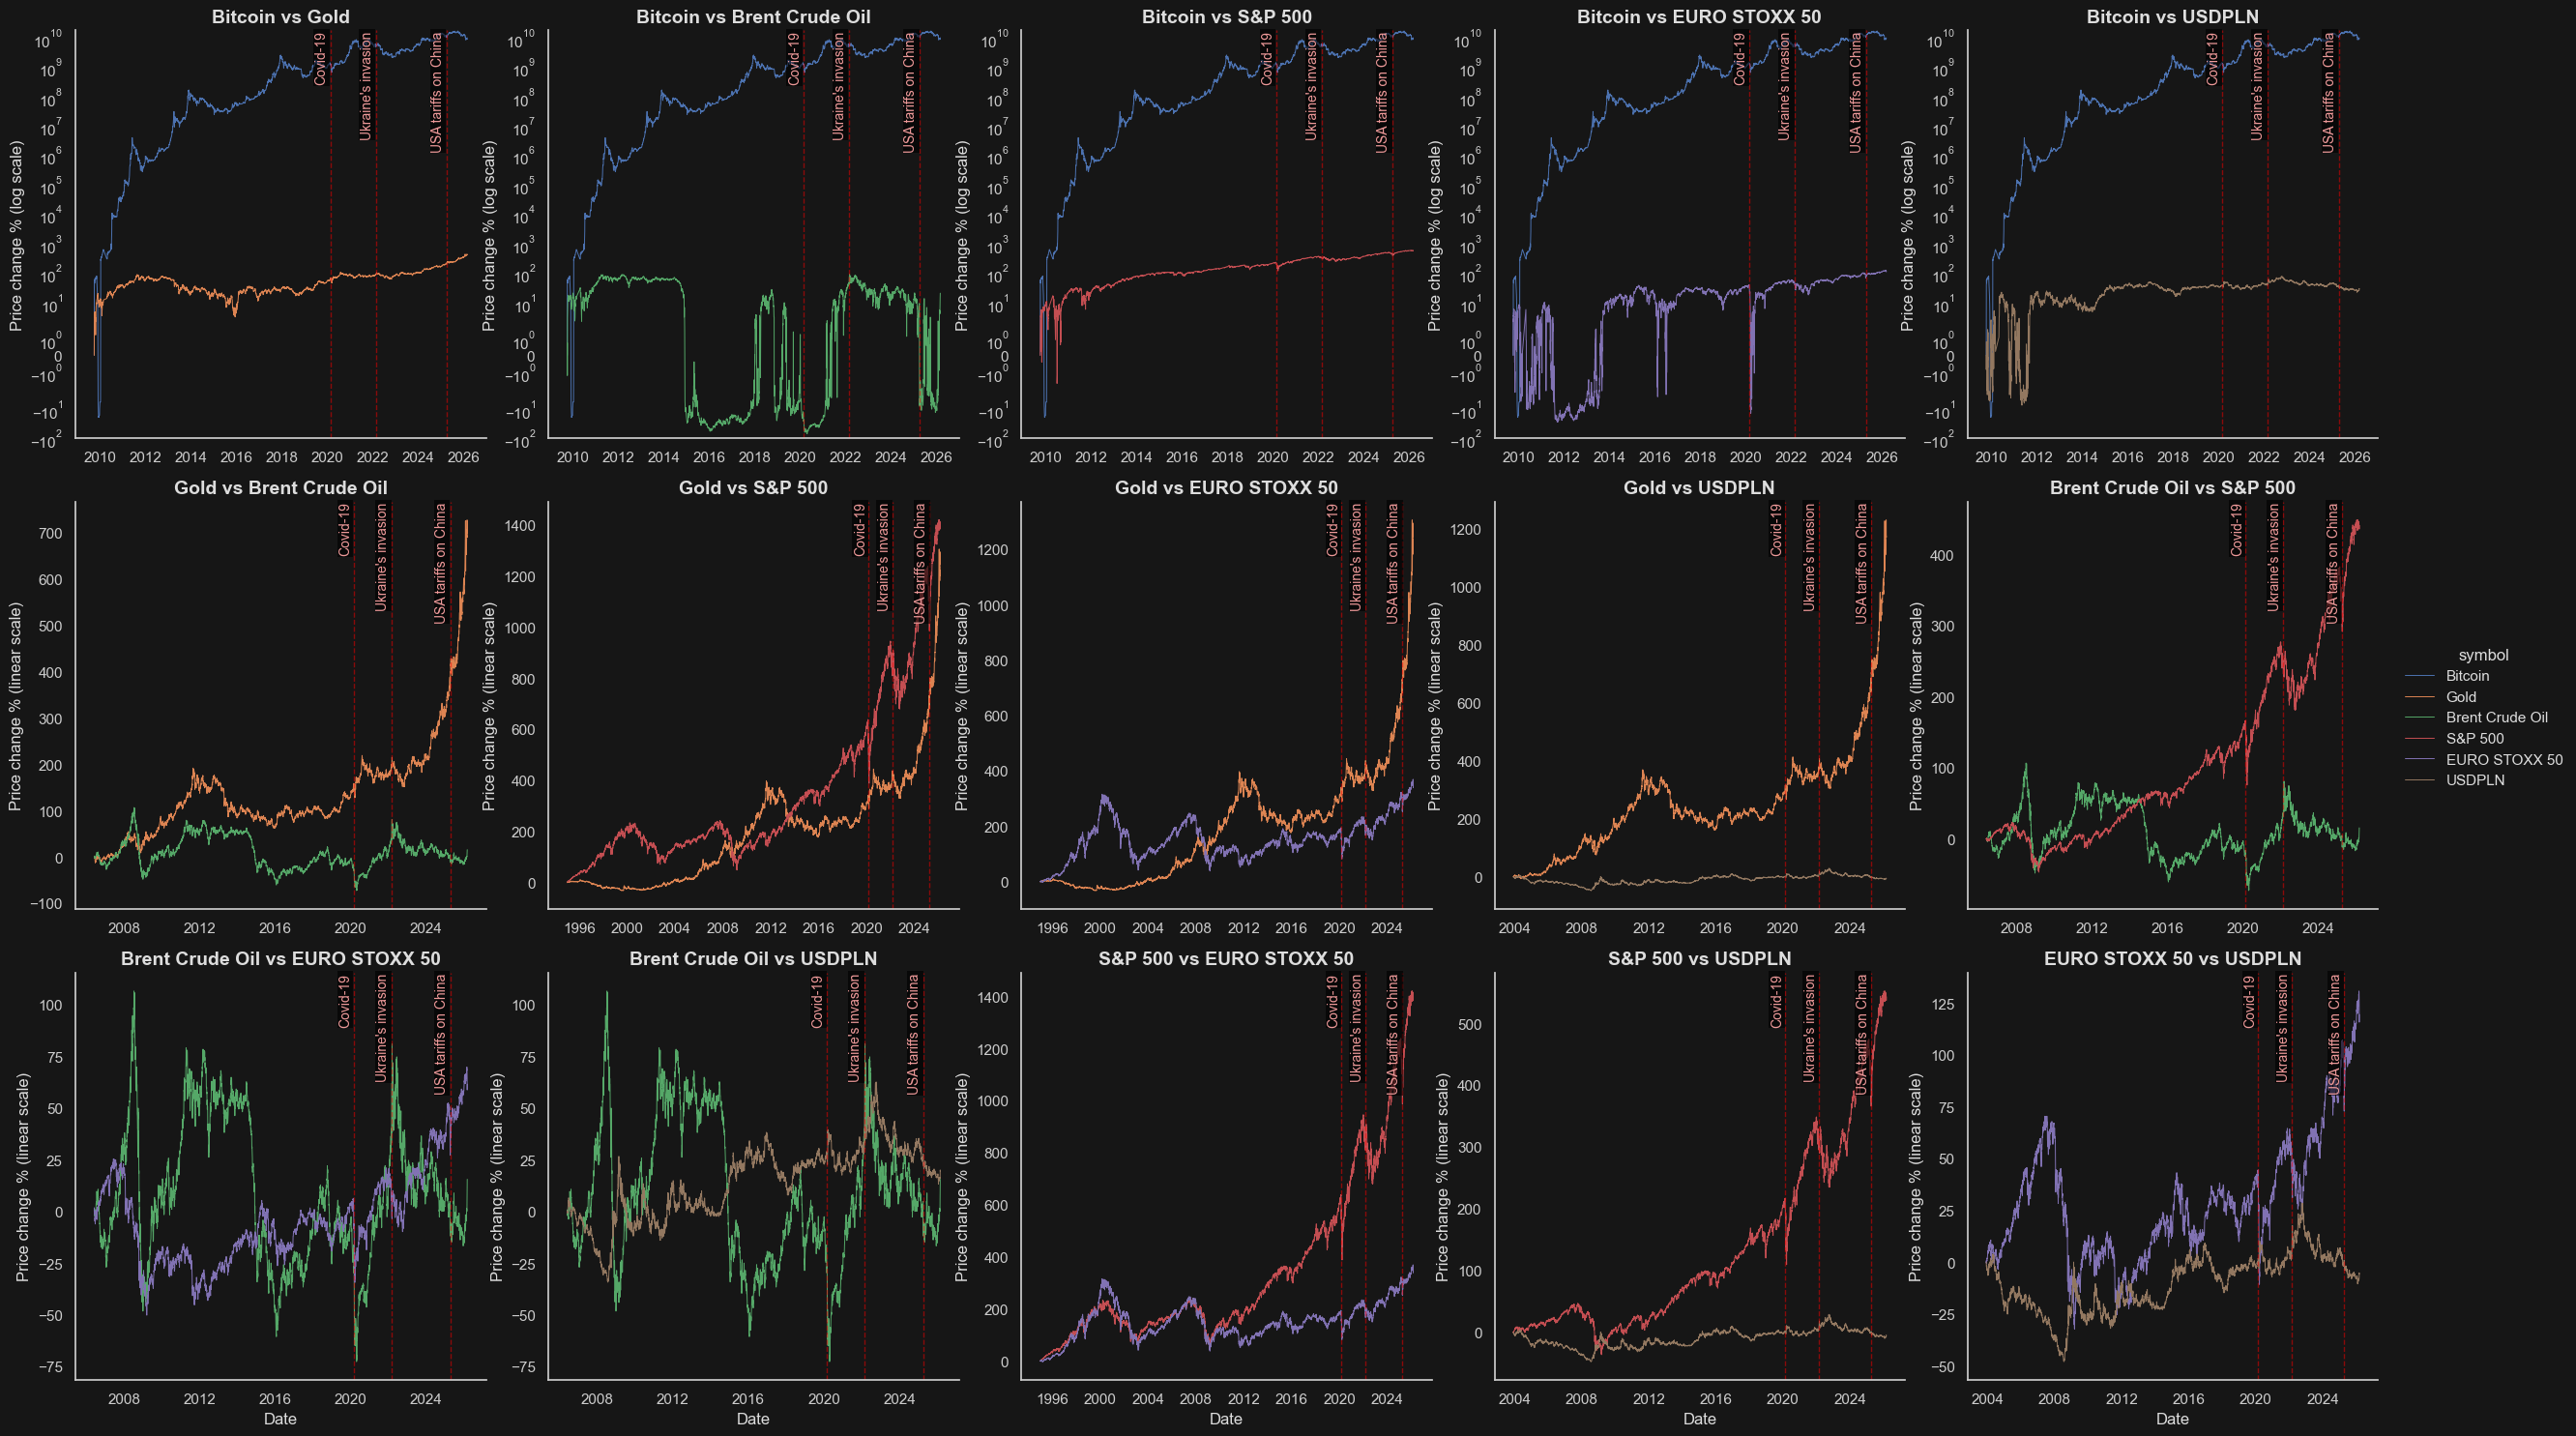

In [17]:
combinations = aly.make_pairs(selected)

pl.comparison_plot(data.close_prices, combinations)


### 4. Trends and volatility
---

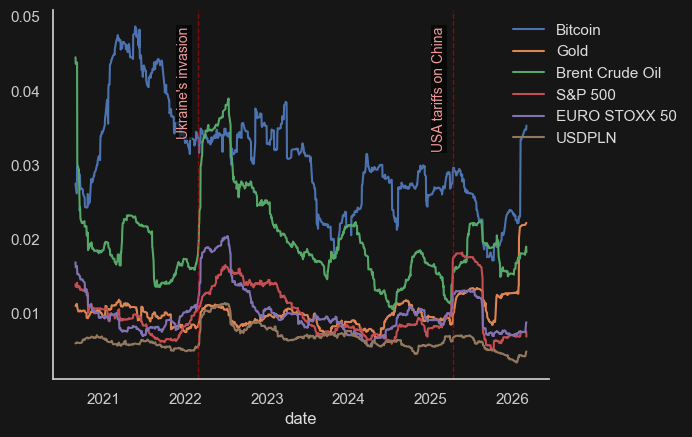

In [13]:
pl.rolling_volatility_plot(returns_sel, window=60)

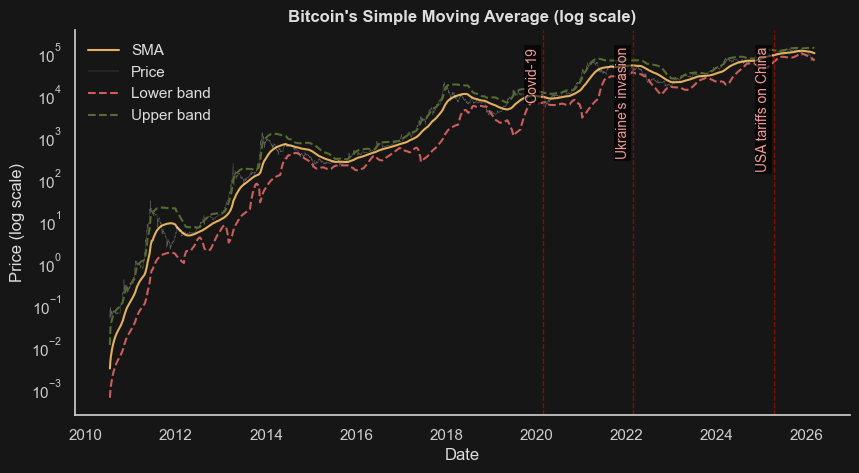

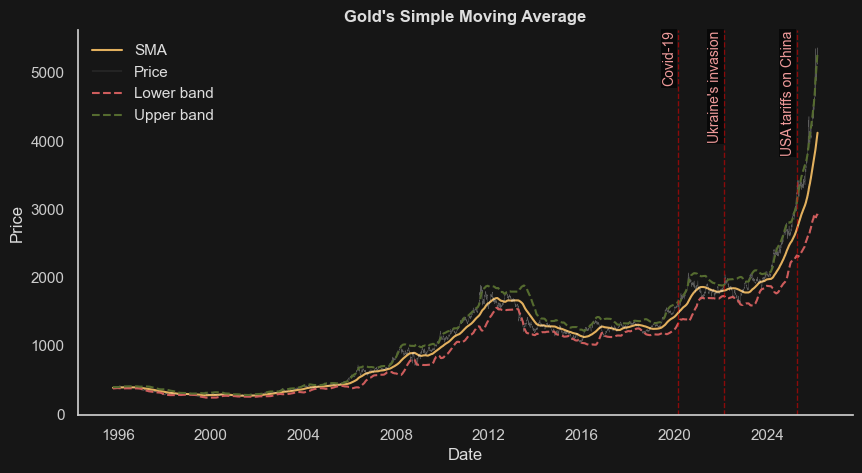

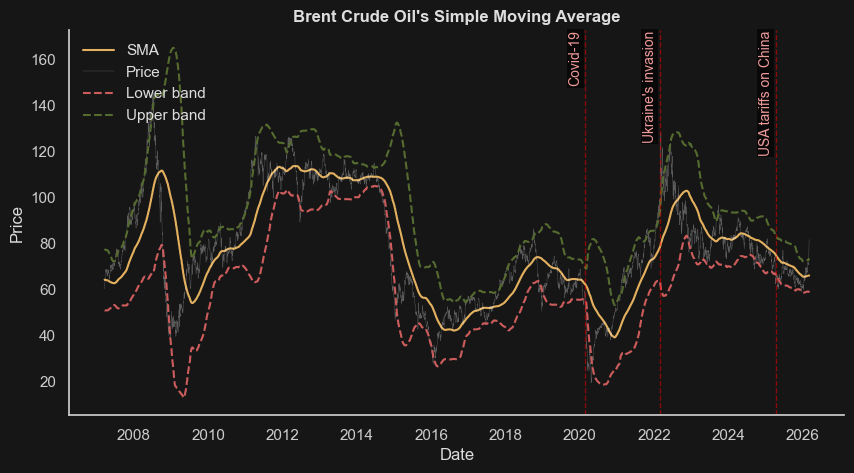

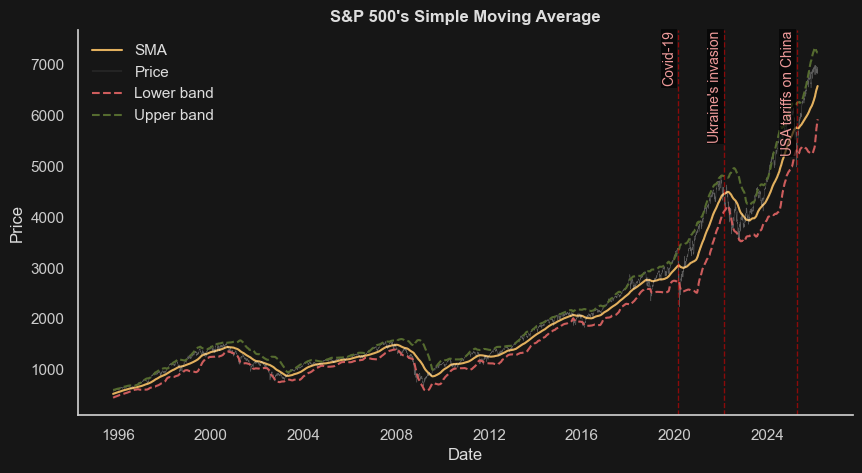

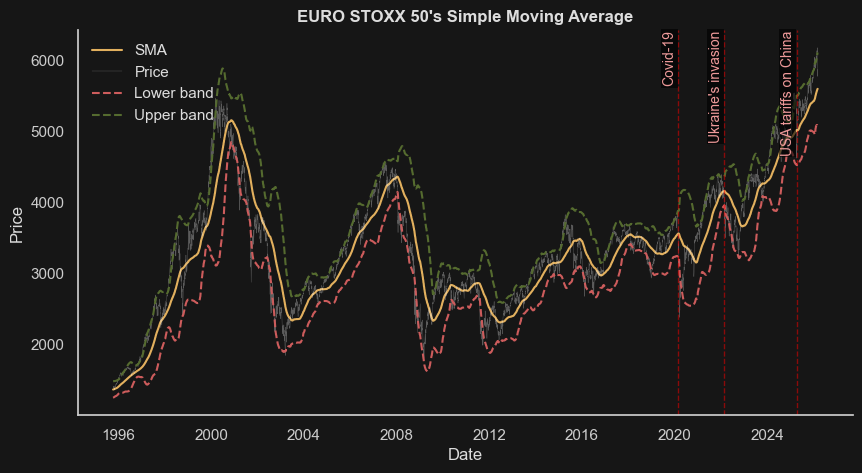

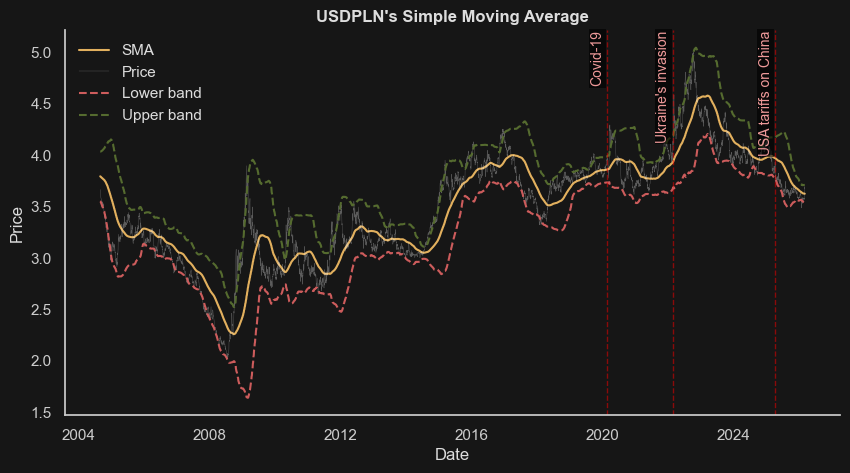

In [14]:
pl.sma_change_plot(data.close_prices, selected)

### 5. Long term hypothetical investment strategy
---

In [ ]:
from src.investment_strategy_simulation import investment_strategy_sim
symbols_list = ["Brent Crude Oil", "Gold", "Silver", "Bitcoin", "Ethereum", "USDPLN", "Dow Jones", "S&P 500",
     "NASDAQ", "Russell 2000", "VIX"]

investment_strategy_sim(data.close_prices, symbols_list)


### 6. Summary
---